In [73]:
#imports
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [74]:
#Dataset Loading
game = pd.read_csv('train.csv', nrows = 10000000) #loading first 10 million rows to safely explore the data
labels = pd.read_csv('train_labels.csv', nrows = 10000000)

last_session = game['session_id'].iloc[-1] #removes the last session to explore only complete sessions
game = game[game['session_id'] != last_session]
labels = labels[labels['session_id'] != last_session]
labels[['session_id', 'question']] = labels['session_id'].str.rsplit('_q', n = 1, expand = True) #splitting session_id in lables to extract question number
labels['session_id'] = labels['session_id'].astype(np.int64)
labels['question'] = labels['question'].astype(np.int64)

In [75]:
#Initial Look
print(f'Dataset preview (dataset shape: {game.shape}):')
display(game) #head and tail of dataset
print('Numerical features:')
display(game.describe()) #statistics of numerical features
print('Categorical features:')
display(game.describe(include = 'object')) #statistics of categorical features

Dataset preview (dataset shape: (9999388, 20)):


,session_id,index,elapsed_time,event_name,name,level,page,room_coor_x,room_coor_y,screen_coor_x,screen_coor_y,hover_duration,text,fqid,room_fqid,text_fqid,fullscreen,hq,music,level_group
0,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,undefined,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4
1,20090312431273200,1,1323,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,"Whatcha doing over there, Jo?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
2,20090312431273200,2,831,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,Just talking to Teddy.,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
3,20090312431273200,3,1147,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,I gotta run to my meeting!,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
4,20090312431273200,4,1863,person_click,basic,0,NaN,-412.991405,-159.314686,381.0,494.0,NaN,"Can I come, Gramps?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999383,21020511384654296,1113,3329972,navigate_click,undefined,22,NaN,43.121045,-294.722056,463.0,629.0,NaN,NaN,toentry,tunic.historicalsociety.stacks,NaN,0,0,0,13-22
9999384,21020511384654296,1114,3331606,navigate_click,undefined,22,NaN,866.801132,-16.504045,887.0,343.0,NaN,NaN,tomap,tunic.historicalsociety.entry,NaN,0,0,0,13-22
9999385,21020511384654296,1115,3335019,map_click,undefined,22,NaN,509.898993,18.397833,489.0,326.0,NaN,NaN,tunic.capitol_2,tunic.historicalsociety.entry,NaN,0,0,0,13-22
9999386,21020511384654296,1116,3335613,navigate_click,undefined,22,NaN,197.867926,-11.201072,396.0,312.0,NaN,NaN,chap4_finale_c,tunic.capitol_2.hall,NaN,0,0,0,13-22


Numerical features:


,session_id,index,elapsed_time,level,page,room_coor_x,room_coor_y,screen_coor_x,screen_coor_y,hover_duration,fullscreen,hq,music
count,9.999388e+06,9.999388e+06,9.999388e+06,9.999388e+06,213540.000000,9.153810e+06,9.153810e+06,9.153810e+06,9.153810e+06,8.187700e+05,9.999388e+06,9.999388e+06,9.999388e+06
mean,2.069079e+16,6.634446e+02,2.742829e+06,1.221362e+01,3.139861,-5.522191e+01,-1.147793e+02,4.569273e+02,3.843082e+02,2.617396e+03,1.254885e-01,1.233246e-01,9.087314e-01
std,4.321353e+14,6.828978e+02,1.956649e+07,6.492560e+00,2.065456,5.180266e+02,2.178838e+02,2.466206e+02,1.298466e+02,2.981411e+05,3.312720e-01,3.288095e-01,2.879907e-01
min,2.009031e+16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.991220e+03,-9.180786e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.011031e+16,2.900000e+02,4.488610e+05,6.000000e+00,1.000000,-3.521224e+02,-2.117316e+02,2.690000e+02,3.030000e+02,9.900000e+01,0.000000e+00,0.000000e+00,1.000000e+00
50%,2.100041e+16,5.990000e+02,1.035232e+06,1.300000e+01,3.000000,-1.156836e+01,-9.628596e+01,4.460000e+02,3.950000e+02,4.170000e+02,0.000000e+00,0.000000e+00,1.000000e+00
75%,2.101051e+16,9.020000e+02,1.781291e+06,1.800000e+01,5.000000,2.932180e+02,2.384634e+01,6.580000e+02,4.700000e+02,1.213000e+03,0.000000e+00,0.000000e+00,1.000000e+00
max,2.102051e+16,2.047300e+04,1.128110e+09,2.200000e+01,6.000000,1.261774e+03,5.436164e+02,1.919000e+03,1.440000e+03,1.594609e+08,1.000000e+00,1.000000e+00,1.000000e+00


Categorical features:


,event_name,name,text,fqid,room_fqid,text_fqid,level_group
count,9999388,9999388,3622925,6868328,9999388,3622960,9999388
unique,11,6,566,127,19,126,3
top,navigate_click,undefined,undefined,worker,tunic.historicalsociety.entry,tunic.historicalsociety.cage.confrontation,13-22
freq,4286966,4835515,132885,707911,1373589,248956,5119115


In [76]:
rows = [] #building a feature table to look at their properties
n = len(game)

for col in game.columns:
    feat = game[col]
        
    unique_count = feat.nunique(dropna = True)
    missing_count = feat.isna().sum()
    missing_pct = missing_count / n

    if pd.api.types.is_numeric_dtype(feat):
        ftype = 'numerical'
    else:
        ftype = 'categorical'

    rows.append({
        'feature': col,
        'type': ftype,
        'unique_count': unique_count,
        'missing_count': missing_count,
        'missing_%': missing_pct,
        'sample_values': feat.dropna().unique()[:3]
    })

feature_table = pd.DataFrame(rows)
display(feature_table)

,feature,type,unique_count,missing_count,missing_%,sample_values
0,session_id,numerical,8892,0,0.000000,"[20090312431273200, 20090312433251036, 2009031..."
1,index,numerical,20348,0,0.000000,"[0, 1, 2]"
2,elapsed_time,numerical,3389800,0,0.000000,"[0, 1323, 831]"
3,event_name,categorical,11,0,0.000000,"[cutscene_click, person_click, navigate_click]"
4,name,categorical,6,0,0.000000,"[basic, undefined, close]"
5,level,numerical,23,0,0.000000,"[0, 1, 2]"
6,page,numerical,7,9785848,0.978645,"[0.0, 1.0, 3.0]"
7,room_coor_x,numerical,6930626,845578,0.084563,"[-413.9914052226322, -412.9914052226322, 478.4..."
8,room_coor_y,numerical,5317036,845578,0.084563,"[-159.31468617022784, -157.31468617022784, -19..."
9,screen_coor_x,numerical,24163,845578,0.084563,"[380.0, 381.0, 593.0]"


In [77]:
event_counts = game['event_name'].value_counts().reset_index() #counting unique values of event_name and name features, mainly to double check if some columns with missing values are actually missing
display(event_counts) #event counts show features missing values are valid because some are only for certain events

,event_name,count
0,navigate_click,4286966
1,person_click,2281806
2,cutscene_click,1015790
3,object_click,831982
4,object_hover,428770
5,map_hover,390000
6,notification_click,243457
7,notebook_click,213540
8,map_click,198362
9,observation_click,81907


In [78]:
session_agg = defaultdict(lambda: { #initializing a dictionary to store aggregated features for each session
    'event_count': 0,
    'elapsed_time_sum': 0,
    'elapsed_time_count': 0,
    'level_sum': 0,
    'event_counts': {}
})

def entropy(counter): #calculating entropy from a counter of event_name frequencies
    vals = np.array(list(counter.values()))
    probs = vals / vals.sum()
    return - (probs * np.log2(probs)).sum() if len(probs) > 0 else 0

chunk_size = 100_000

for chunk in pd.read_csv('train.csv', chunksize = chunk_size): #processing the dataset in chunks to handle memory constraints

    for row in chunk.itertuples(index = False):
        s = row.session_id
        agg = session_agg[s]

        agg['event_count'] += 1 #counting the number of events in each session

        if pd.notna(row.elapsed_time): #summing elapsed_time and counting non-missing values for later calculation of mean elapsed time
            agg['elapsed_time_sum'] += row.elapsed_time
            agg['elapsed_time_count'] += 1

        if pd.notna(row.level): #summing level for later calculation of mean level
            agg['level_sum'] += row.level

        e = row.event_name #counting the frequency of each event_name in the session for later calculation of event entropy
        agg['event_counts'][e] = agg['event_counts'].get(e, 0) + 1

rows = []

for session_id, agg in session_agg.items(): #building a feature table for each session based on the aggregated features

    event_count = agg['event_count'] #total number of events in the session
    elapsed_sum = agg['elapsed_time_sum'] #total elapsed time in the session
    elapsed_count = max(agg['elapsed_time_count'], 1) #number of non-missing elapsed_time values in the session (used to calculate mean elapsed time, avoiding division by zero)

    rows.append({
        'session_id': session_id,

        'event_count': event_count,
        'elapsed_time_sum': elapsed_sum,

        'level_mean': agg['level_sum'] / max(event_count, 1),

        'event_entropy': entropy(agg['event_counts']),
        'time_per_event': elapsed_sum / max(event_count, 1),
        'events_per_second': event_count / max(elapsed_sum, 1)
    })

session_features = pd.DataFrame(rows) #creates dataset based on sessions

session_data = labels.merge(session_features, on = 'session_id', how = 'left') #merges said dataset with features from train_labels.csv

question_difficulty = labels.groupby('question')['correct'].mean()
session_data['question_difficulty'] = session_data['question'].map(question_difficulty) #creates column for question difficulty

session_data.fillna(0, inplace = True) #filling missing values with 0 for readability

In [79]:
display(session_data) #displaying new dataset preview and statistics
display(session_data.describe())

,session_id,correct,question,event_count,elapsed_time_sum,level_mean,event_entropy,time_per_event,events_per_second,question_difficulty
0,20090312431273200,1,1,881,556940995,11.366629,2.359645,6.321691e+05,1.581855e-06,0.727485
1,20090312433251036,0,1,1831,3473769473,14.631349,2.566011,1.897198e+06,5.270931e-07,0.727485
2,20090312455206810,1,1,758,503415294,11.514512,2.585101,6.641363e+05,1.505715e-06,0.727485
3,20090313091715820,0,1,993,803312603,11.573011,2.452223,8.089754e+05,1.236131e-06,0.727485
4,20090313571836404,1,1,746,464468352,12.057641,2.446809,6.226117e+05,1.606137e-06,0.727485
...,...,...,...,...,...,...,...,...,...,...
424111,22100215342220508,1,18,873,7943698394,11.851088,2.603918,9.099311e+06,1.098984e-07,0.950641
424112,22100215460321130,1,18,985,1087071730,11.254822,2.661844,1.103626e+06,9.061040e-07,0.950641
424113,22100217104993650,1,18,1199,1279947094,12.101751,2.514655,1.067512e+06,9.367575e-07,0.950641
424114,22100219442786200,1,18,868,529258655,11.570276,2.520375,6.097450e+05,1.640030e-06,0.950641


,session_id,correct,question,event_count,elapsed_time_sum,level_mean,event_entropy,time_per_event,events_per_second,question_difficulty
count,4.241160e+05,424116.000000,424116.000000,424116.000000,4.241160e+05,424116.000000,424116.000000,4.241160e+05,4.241160e+05,424116.000000
mean,2.113666e+16,0.705635,9.500000,1116.074442,4.482929e+09,12.119639,2.408208,3.750879e+06,1.062820e-06,0.705635
std,5.704008e+14,0.455757,5.188134,352.844960,2.971759e+10,0.749267,0.195772,2.258672e+07,1.208607e-05,0.173352
min,2.009031e+16,0.000000,1.000000,591.000000,3.871180e+05,7.302968,1.180164,5.391616e+02,9.360627e-10,0.275104
25%,2.101031e+16,0.000000,5.000000,901.000000,7.592502e+08,11.659696,2.321039,7.883336e+05,6.800383e-07,0.617223
50%,2.104022e+16,1.000000,9.500000,1033.000000,1.103108e+09,12.025383,2.440033,1.033569e+06,9.675213e-07,0.731177
75%,2.110061e+16,1.000000,14.000000,1231.000000,1.798582e+09,12.482637,2.537853,1.470505e+06,1.268499e-06,0.798234
max,2.210022e+16,1.000000,18.000000,19032.000000,1.962317e+12,17.376311,2.857176,1.068305e+09,1.854732e-03,0.978822


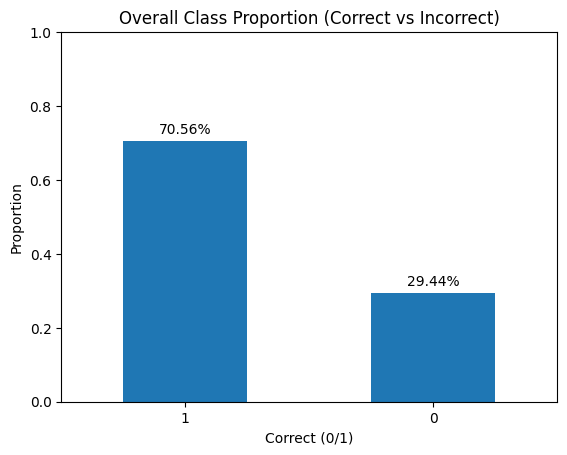

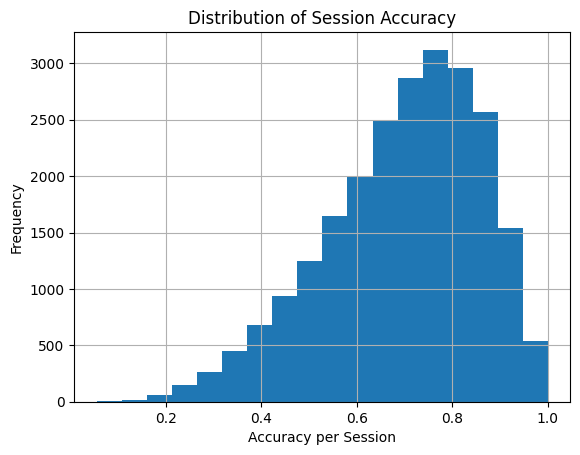


Per-question stats:


,accuracy,count
question,,
1,0.727485,23562
2,0.978822,23562
3,0.934004,23562
4,0.798234,23562
5,0.548256,23562
6,0.775953,23562
7,0.736058,23562
8,0.617223,23562
9,0.736270,23562


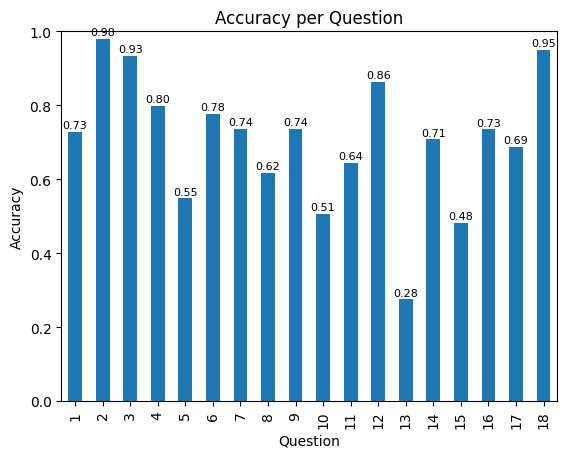

In [80]:
if 'question' not in labels.columns:
    labels[['session_id', 'question']] = labels['session_id'].str.rsplit('_q', n = 1, expand = True)
    labels['question'] = labels['question'].astype(int)

class_props = labels['correct'].value_counts(normalize = True)

ax = class_props.plot(kind = 'bar') #bar graph showing class imbalance
plt.title('Overall Class Proportion (Correct vs Incorrect)')
plt.xlabel('Correct (0/1)')
plt.ylabel('Proportion')
plt.xticks(rotation = 0)

for i, v in enumerate(class_props.values):
    ax.text(i, v + 0.01, f'{v:.2%}', ha = 'center', va = 'bottom')

plt.ylim(0, 1)
plt.show()

session_acc = labels.groupby('session_id')['correct'].mean()

session_acc.hist(bins=18) #histogram showing proportion of sessions getting a question correct
plt.title('Distribution of Session Accuracy')
plt.xlabel('Accuracy per Session')
plt.ylabel('Frequency')
plt.show()

question_stats = pd.DataFrame(labels.groupby('question').agg( #table showing accuracy per question
    accuracy = ('correct', 'mean'),
    count = ('correct', 'count')
).sort_index())

print('\nPer-question stats:')
display(question_stats)

ax = question_stats['accuracy'].plot(kind = 'bar') #bar graph showing accuracy per question
plt.title('Accuracy per Question')
plt.xlabel('Question')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for i, v in enumerate(question_stats['accuracy']):
    ax.text(i, v + 0.01, f'{v:.2f}', ha = 'center', fontsize = 8)

plt.show()

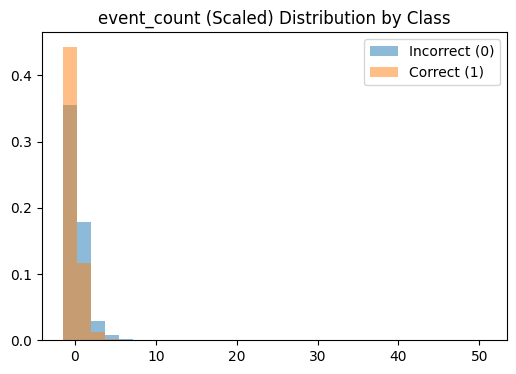

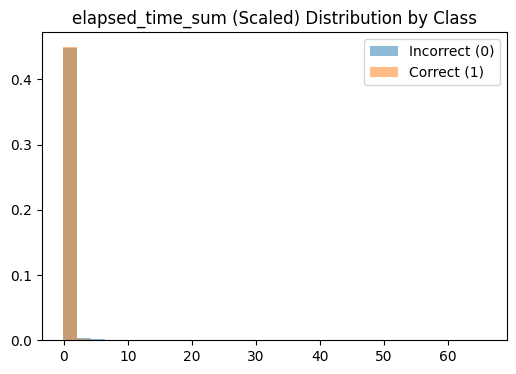

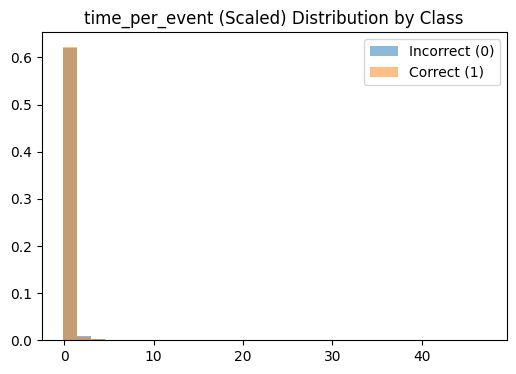

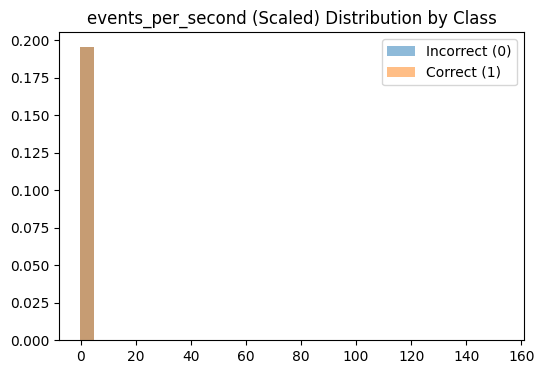

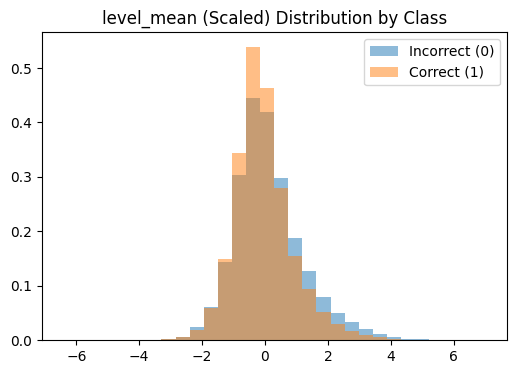

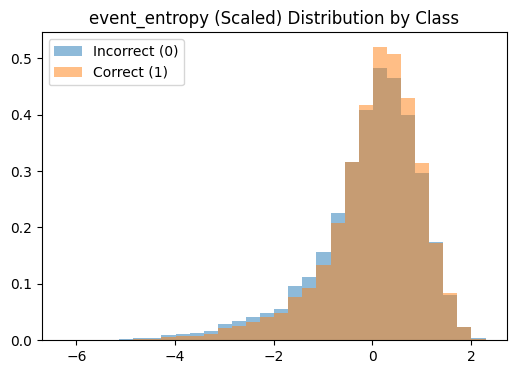

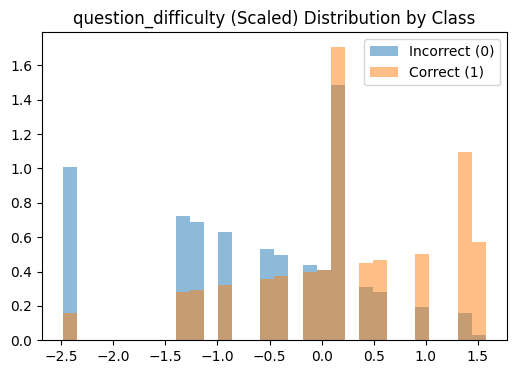

In [81]:
scaler = StandardScaler() #scaling all features that can/should be scaled (at least for logistic regression)

scaled_df = session_data.copy()
scaled_df[feature_cols] = scaler.fit_transform(session_data[feature_cols])

for col in feature_cols: #making histograms for each one while also showing class imbalance
    plt.figure(figsize = (6,4))
    
    plt.hist(
        scaled_df[scaled_df['correct'] == 0][col],
        bins = 30,
        alpha = 0.5,
        label = 'Incorrect (0)',
        density = True
    )
    
    plt.hist(
        scaled_df[scaled_df['correct'] == 1][col],
        bins = 30,
        alpha = 0.5,
        label = 'Correct (1)',
        density = True
    )
    
    plt.title(f'{col} (Scaled) Distribution by Class')
    plt.legend()
    plt.show()

correct,0,1
event_count,1.212301e+03,1.075932e+03
elapsed_time_sum,5.527616e+09,4.047124e+09
time_per_event,4.193364e+06,3.566290e+06
events_per_second,9.259573e-07,1.119914e-06
level_mean,1.220727e+01,1.208308e+01
event_entropy,2.394981e+00,2.413726e+00
question_difficulty,6.035477e-01,7.482218e-01


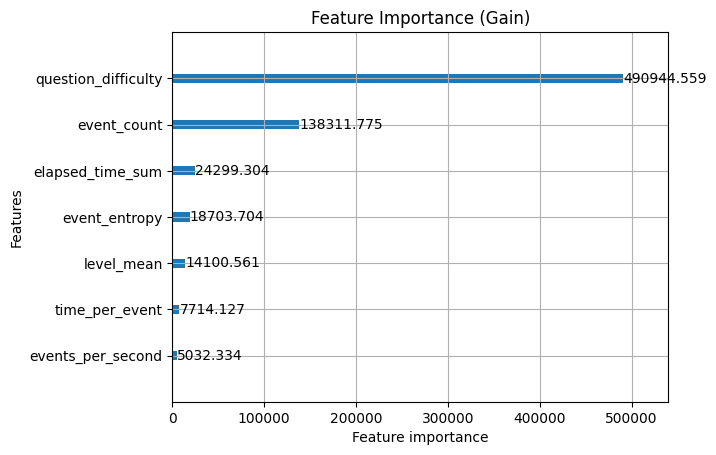

'Based on the histograms, the table, and the graph, question difficulty and event count appear to be the most influential features for machine learning.'

In [82]:
display(session_data.groupby('correct')[feature_cols].mean().T) #table comparing means of each class for each feature
lgb.plot_importance(lgb_model, importance_type = 'gain') #Feature importance graph extracted by LightGBM
plt.title("Feature Importance (Gain)")
plt.show()
'''Based on the histograms, the table, and the graph, question difficulty and event count appear to be the most influential features for machine learning.'''

In [83]:
model_features = [
    'event_count',
    'elapsed_time_sum',
    'time_per_event',
    'events_per_second',
    'level_mean',
    'event_entropy',
    'question_difficulty'
]

X = session_data[model_features].copy() #establishing input and output for ML
y = session_data['correct']

X_train, X_temp, y_train, y_temp = train_test_split( #establishing training splits: 70% - training, 15% - validation, 15% - evaluation
    X, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
)

scaler = StandardScaler() #scaling for logistic regression model

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [84]:
#model training: logistic regression, random forest classifier, and LightGBM
lr = LogisticRegression(max_iter = 1000) #logistic regression
lr.fit(X_train_scaled, y_train)

lr_val_pred = lr.predict_proba(X_val_scaled)[:, 1] #random forest

rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)

rf.fit(X_train, y_train)

rf_val_pred = rf.predict_proba(X_val)[:, 1]

lgb_model = lgb.LGBMClassifier( #LightGBM
    n_estimators = 300,
    learning_rate = 0.05,
    random_state = 42
)

lgb_model.fit(X_train, y_train)

lgb_val_pred = lgb_model.predict_proba(X_val)[:, 1]

[LightGBM] [Info] Number of positive: 209490, number of negative: 87391
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1549
[LightGBM] [Info] Number of data points in the train set: 296881, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.705636 -> initscore=0.874284
[LightGBM] [Info] Start training from score 0.874284


LogReg AUC: 0.7641923845979961
RF AUC: 0.7517860227399105
LGBM AUC: 0.7744933019671577


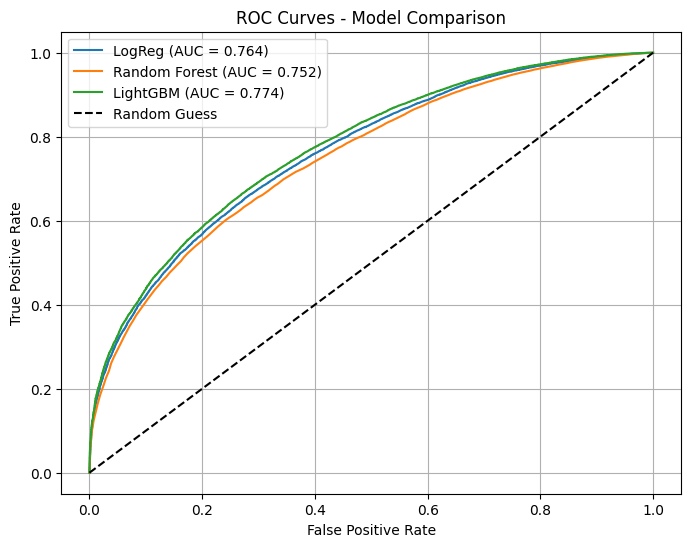

In [85]:
print("LogReg AUC:", roc_auc_score(y_val, lr_val_pred)) #comparing ROC AUC scores between models; LightGBM performed the best
print("RF AUC:", roc_auc_score(y_val, rf_val_pred))
print("LGBM AUC:", roc_auc_score(y_val, lgb_val_pred))
plt.figure(figsize=(8,6))

#logistic regression
fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_val_pred)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc_lr:.3f})')

# random forest
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_pred)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, lgb_val_pred)
auc_lgb = auc(fpr_lgb, tpr_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.3f})')

# Diagonal baseline
plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.title('ROC Curves - Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

In [86]:
best_model = lgb.LGBMClassifier( #finalizing LightGBM as the definitive model for test.csv
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

best_model.fit(X, y)

[LightGBM] [Info] Number of positive: 299271, number of negative: 124845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1549
[LightGBM] [Info] Number of data points in the train set: 424116, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.705635 -> initscore=0.874277
[LightGBM] [Info] Start training from score 0.874277


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [87]:
test = pd.read_csv('test.csv') #loading test.csv and sample_submission.csv
submission = pd.read_csv('sample_submission.csv')

def entropy(counter): #making session-based dataset from test.csv, generally same steps from before
    vals = np.array(list(counter.values()))
    if len(vals) == 0:
        return 0
    probs = vals / vals.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

session_agg_test = defaultdict(lambda: {
    'event_count': 0,
    'elapsed_time_sum': 0,
    'level_sum': 0,
    'event_counts': {}
})

for chunk in pd.read_csv('test.csv', chunksize=100000):
    for row in chunk.itertuples(index=False):
        s = row.session_id
        agg = session_agg_test[s]

        agg['event_count'] += 1

        if pd.notna(row.elapsed_time):
            agg['elapsed_time_sum'] += row.elapsed_time

        if pd.notna(row.level):
            agg['level_sum'] += row.level

        e = row.event_name
        agg['event_counts'][e] = agg['event_counts'].get(e, 0) + 1

rows = []

for session_id, agg in session_agg_test.items():
    event_count = agg['event_count']
    elapsed_sum = agg['elapsed_time_sum']

    rows.append({
        'session_id': session_id,
        'event_count': event_count,
        'elapsed_time_sum': elapsed_sum,
        'level_mean': agg['level_sum'] / max(event_count, 1),
        'event_entropy': entropy(agg['event_counts']),
        'time_per_event': elapsed_sum / max(event_count, 1),
        'events_per_second': event_count / max(elapsed_sum, 1)
    })

test_features = pd.DataFrame(rows)
test_features['session_id'] = test_features['session_id'].astype(str)

submission[['session_id', 'question']] = submission['session_id'].str.rsplit('_q', n=1, expand=True) #turning data into a submission file

submission['session_id'] = submission['session_id'].astype(str)
submission['question'] = submission['question'].astype(int)

submission = submission.merge(test_features, on='session_id', how='left')

submission['question_difficulty'] = submission['question'].map(question_difficulty)

submission['question_difficulty'] = submission['question_difficulty'].fillna(
    question_difficulty.mean()
)
submission.replace([np.inf, -np.inf], np.nan, inplace=True) #data cleaning
submission.fillna(0, inplace=True)

model_features = [ #model input
    'event_count',
    'elapsed_time_sum',
    'time_per_event',
    'events_per_second',
    'level_mean',
    'event_entropy',
    'question_difficulty'
]

X_test_final = submission[model_features]

test_preds = best_model.predict_proba(X_test_final)[:, 1] #LightGBM making predictions based off training

test_preds_binary = (test_preds >= 0.5).astype(int) #converting probabilities to binary choices (correct - 1, incorrect - 0)

final_submission = pd.DataFrame({
    'session_id': submission['session_id'].astype(str) + "_q" + submission['question'].astype(str),
    'correct': test_preds_binary,
    'session_level': submission['session_level']
})

final_submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")

Submission file created successfully!


In [88]:
print(final_submission.head()) #double checking submission file format
print(final_submission.shape)
print(final_submission.columns)
final_submission['correct'].describe()

             session_id  correct  session_level
0  20090109393214576_q1        1              0
1  20090312143683264_q1        1              3
2  20090312331414616_q1        1              6
3  20090109393214576_q2        1              0
4  20090312143683264_q2        1              3
(54, 3)
Index(['session_id', 'correct', 'session_level'], dtype='object')


count    54.000000
mean      0.796296
std       0.406533
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: correct, dtype: float64